In [103]:
import sys
print(sys.version)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

In [107]:
df = pd.read_csv('Downloads/home-credit-default-risk/application_train.csv')


In [108]:
df.shape

(307511, 122)

In [109]:
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [125]:
df.dtypes

SK_ID_CURR                             int64
TARGET                                 int64
NAME_CONTRACT_TYPE                    object
CODE_GENDER                           object
FLAG_OWN_CAR                          object
                                       ...  
AMT_REQ_CREDIT_BUREAU_WEEK_missing     int64
AMT_REQ_CREDIT_BUREAU_MON_missing      int64
AMT_REQ_CREDIT_BUREAU_QRT_missing      int64
AMT_REQ_CREDIT_BUREAU_HOUR_missing     int64
AMT_REQ_CREDIT_BUREAU_YEAR_missing     int64
Length: 114, dtype: object

In [111]:
sentinel_count = (df['DAYS_EMPLOYED'] == 365243).sum()
sentinel_pct = sentinel_count / len(df) * 100
sentinel_pct

np.float64(18.00716071945394)

In [112]:
df.loc[df['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan

In [113]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({
    'Column': missing_pct.index,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': missing_pct.values
})
high_missing_40 = missing_df[missing_df['Missing_Percentage'] > 40].copy()

In [114]:
drop_cols = []
keep_with_indicator = []

for _, row in high_missing_40.iterrows():
    col = row['Column']
    pct = row['Missing_Percentage']
    if pct > 60:
        drop_cols.append(col)
    else:
        keep_with_indicator.append(col)


In [115]:
print(f"\n DROP (>60% missing) - {len(drop_cols)} features (Not enough data to be useful):")
if drop_cols:
    for col in drop_cols:
        print(f"  - {col}: {missing_pct[col]:.1f}% missing")

print(f"\n KEEP WITH INDICATOR (40-60% missing) - {len(keep_with_indicator)} features (Create missing indicator and impute):")
for col in keep_with_indicator:
    print(f"   • {col}: {missing_pct[col]:.1f}% missing")

df = df.drop(columns=drop_cols)



 DROP (>60% missing) - 17 features (Not enough data to be useful):
  - COMMONAREA_AVG: 69.9% missing
  - COMMONAREA_MODE: 69.9% missing
  - COMMONAREA_MEDI: 69.9% missing
  - NONLIVINGAPARTMENTS_AVG: 69.4% missing
  - NONLIVINGAPARTMENTS_MODE: 69.4% missing
  - NONLIVINGAPARTMENTS_MEDI: 69.4% missing
  - FONDKAPREMONT_MODE: 68.4% missing
  - LIVINGAPARTMENTS_MEDI: 68.4% missing
  - LIVINGAPARTMENTS_AVG: 68.4% missing
  - LIVINGAPARTMENTS_MODE: 68.4% missing
  - FLOORSMIN_AVG: 67.8% missing
  - FLOORSMIN_MODE: 67.8% missing
  - FLOORSMIN_MEDI: 67.8% missing
  - YEARS_BUILD_AVG: 66.5% missing
  - YEARS_BUILD_MEDI: 66.5% missing
  - YEARS_BUILD_MODE: 66.5% missing
  - OWN_CAR_AGE: 66.0% missing

 KEEP WITH INDICATOR (40-60% missing) - 32 features (Create missing indicator and impute):
   • LANDAREA_MEDI: 59.4% missing
   • LANDAREA_AVG: 59.4% missing
   • LANDAREA_MODE: 59.4% missing
   • BASEMENTAREA_AVG: 58.5% missing
   • BASEMENTAREA_MEDI: 58.5% missing
   • BASEMENTAREA_MODE: 58.5% 

In [116]:
missing_5_40 = missing_pct[(missing_pct > 5) & (missing_pct <= 40)].index.tolist()
indicator_cols = []
for col in missing_5_40:
    indicator_name = f'{col}_missing'
    df[indicator_name] = df[col].isnull().astype(int)
    indicator_cols.append(indicator_name)

X_missing = df[indicator_cols].fillna(0)
y = df['TARGET']

lr_missing = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_missing.fit(X_missing, y)
y_pred = lr_missing.predict_proba(X_missing)[:, 1]
auroc = roc_auc_score(y, y_pred)

if auroc > 0.55:
    print(f" Missingness is predictive of target (AUROC > 0.55)")
    print(f" Keeping missing indicators as features")
else:
    print(f" Missingness weakly predictive of target (AUROC ≤ 0.55)")
    print(f" Consider dropping if dimensionality is an issue")

coef_df = pd.DataFrame({
    'Indicator': indicator_cols,
    'Coefficient': lr_missing.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\n Top 5 most predictive missingness indicators:")
print("   (Positive coefficient = missing INCREASES default risk)")
for _, row in coef_df.head(5).iterrows():
    impact = "Higher Risk" if row['Coefficient'] > 0 else "Lower Risk"
    orig_col = row['Indicator'].replace('_missing', '')
    print(f"   - {row['Indicator']:35} | Coef: {row['Coefficient']:+.4f} → {impact}")

 Missingness is predictive of target (AUROC > 0.55)
 Keeping missing indicators as features

 Top 5 most predictive missingness indicators:
   (Positive coefficient = missing INCREASES default risk)
   - AMT_REQ_CREDIT_BUREAU_DAY_missing   | Coef: +0.0687 → Higher Risk
   - AMT_REQ_CREDIT_BUREAU_WEEK_missing  | Coef: +0.0687 → Higher Risk
   - AMT_REQ_CREDIT_BUREAU_MON_missing   | Coef: +0.0687 → Higher Risk
   - AMT_REQ_CREDIT_BUREAU_QRT_missing   | Coef: +0.0687 → Higher Risk
   - AMT_REQ_CREDIT_BUREAU_HOUR_missing  | Coef: +0.0687 → Higher Risk


In [117]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

cols_to_exclude = ['TARGET'] + indicator_cols
numeric_to_impute = [col for col in numeric_cols if col not in cols_to_exclude and df[col].isnull().any()]
categorical_to_impute = [col for col in categorical_cols if col not in cols_to_exclude and df[col].isnull().any()]

imputation_values = {}
for col in numeric_to_impute:
    median_val = df[col].median()
    imputation_values[col] = median_val
    null_count = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f"   - {col:35} | Median: {median_val:>12,.2f} | Imputed: {null_count:>6,} values")

for col in categorical_to_impute:
    mode_val = df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown'
    imputation_values[col] = mode_val
    null_count = df[col].isnull().sum()
    df[col] = df[col].fillna(mode_val)
    print(f"   - {col:35} | Mode: {str(mode_val):<20} | Imputed: {null_count:>6,} values")

remaining_missing = df.isnull().sum().sum()

   - AMT_ANNUITY                         | Median:    24,903.00 | Imputed:     12 values
   - AMT_GOODS_PRICE                     | Median:   450,000.00 | Imputed:    278 values
   - DAYS_EMPLOYED                       | Median:    -1,648.00 | Imputed: 55,374 values
   - CNT_FAM_MEMBERS                     | Median:         2.00 | Imputed:      2 values
   - EXT_SOURCE_1                        | Median:         0.51 | Imputed: 173,378 values
   - EXT_SOURCE_2                        | Median:         0.57 | Imputed:    660 values
   - EXT_SOURCE_3                        | Median:         0.54 | Imputed: 60,965 values
   - APARTMENTS_AVG                      | Median:         0.09 | Imputed: 156,061 values
   - BASEMENTAREA_AVG                    | Median:         0.08 | Imputed: 179,943 values
   - YEARS_BEGINEXPLUATATION_AVG         | Median:         0.98 | Imputed: 150,007 values
   - ELEVATORS_AVG                       | Median:         0.00 | Imputed: 163,891 values
   - ENTRANCES_A

In [118]:
output_path = 'Documents\\Jarvis\\jarvis_data_eng_Li\\capstone\\data\\preprocessed_train.csv'
df.to_csv(output_path, index=False)

# Customer Segmentation

In [143]:
cluster_features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT','AMT_ANNUITY','DAYS_BIRTH', 'EXT_SOURCE_2','DAYS_EMPLOYED']

In [133]:
df['DAYS_BIRTH'] = (-df['DAYS_BIRTH'] / 365).astype(int)

In [145]:
X_cluster = df[cluster_features]

In [147]:
X_cluster = X_cluster.fillna(0)

scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)


Testing k=2...
   Inertia: 1,473,339
   Silhouette Score: 0.2458

Testing k=3...
   Inertia: 1,230,796
   Silhouette Score: 0.2452

Testing k=4...
   Inertia: 1,031,284
   Silhouette Score: 0.2125

Testing k=5...
   Inertia: 878,625
   Silhouette Score: 0.2333

Testing k=6...
   Inertia: 763,370
   Silhouette Score: 0.2308

Testing k=7...
   Inertia: 705,398
   Silhouette Score: 0.2110

Testing k=8...
   Inertia: 652,916
   Silhouette Score: 0.2123


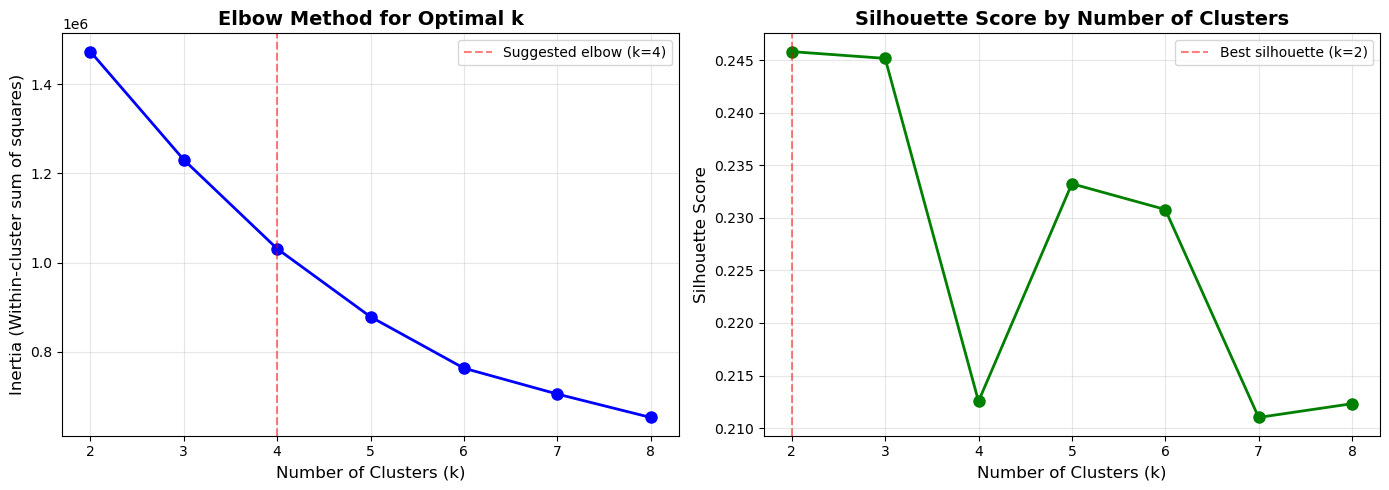


------------------------------------------------------------
RESULTS SUMMARY:
------------------------------------------------------------
k=2: Inertia=1,473,339, Silhouette=0.2458
k=3: Inertia=1,230,796, Silhouette=0.2452
k=4: Inertia=1,031,284, Silhouette=0.2125
k=5: Inertia=878,625, Silhouette=0.2333
k=6: Inertia=763,370, Silhouette=0.2308
k=7: Inertia=705,398, Silhouette=0.2110
k=8: Inertia=652,916, Silhouette=0.2123

🏆 Best k by silhouette score: 2
   (k=4 is also commonly used for credit risk segmentation)


In [149]:
k_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    
    labels = km.labels_
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score by Number of Clusters', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

best_k = k_range[np.argmax(silhouette_scores)]
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.5, 
                label=f'Best silhouette (k={best_k})')
axes[1].legend()

plt.tight_layout()
plt.show()

print("RESULTS SUMMARY:")
for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f"k={k}: Inertia={inertia:,.0f}, Silhouette={sil:.4f}")

print(f"\nBest k by silhouette score: {best_k}")
print(f"   (k=4 is also commonly used for credit risk segmentation)")

optimal_k = best_k if best_k >= 3 else 4

In [156]:
means = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df['customer_segment'] = cluster_labels

scaled_array = scaler_cluster.transform(df[cluster_features].fillna(0))
for idx, feat in enumerate(cluster_features):
    df[f'{feat}_scaled'] = scaled_array[:, idx]

print(f"\nCluster distribution:")
cluster_counts = df['customer_segment'].value_counts().sort_index()
for cluster in sorted(df['customer_segment'].unique()):
    count = cluster_counts[cluster]
    pct = count/len(df)*100
    print(f"   Cluster {cluster}: {count:,} customers ({pct:.1f}%)")


Cluster distribution:
   Cluster 0: 80,732 customers (26.3%)
   Cluster 1: 116,649 customers (37.9%)
   Cluster 2: 110,129 customers (35.8%)
   Cluster 3: 1 customers (0.0%)


In [164]:
profile_features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT','AMT_ANNUITY','DAYS_BIRTH', 'EXT_SOURCE_2','DAYS_EMPLOYED', 'TARGET']
cluster_profiles = df.groupby('customer_segment')[profile_features].mean().round(4)

cluster_profiles['size'] = df['customer_segment'].value_counts().sort_index()
cluster_profiles['size_pct'] = (cluster_profiles['size'] / len(df) * 100).round(1)

cluster_profiles = cluster_profiles.sort_values('TARGET', ascending=False)

segment_names = {}
segment_descriptions = {}

for cluster in cluster_profiles.index:
    row = cluster_profiles.loc[cluster]
    if row['TARGET'] > df['TARGET'].mean() * 1.5:
        if row['EXT_SOURCE_2'] < 0.3:
            name = "HIGH RISK - Poor Credit"
            desc = f"Very low credit score ({row['EXT_SOURCE_2']:.2f}), high default rate"
        elif row['DAYS_EMPLOYED'] < -2000: 
            name = "HIGH RISK - Long Term Unemployed"
            desc = f"Extended unemployment period ({-row['DAYS_EMPLOYED']:.0f} days)"
        else:
            name = "HIGH RISK - Distressed"
            desc = f"High default rate ({row['TARGET']:.2%}), multiple risk factors"
    
    elif row['TARGET'] < df['TARGET'].mean() * 0.5:
        if row['EXT_SOURCE_2'] > 0.7: 
            name = "SUPER PRIME - Excellent Credit"
            desc = f"Excellent credit score ({row['EXT_SOURCE_2']:.2f}), very low default rate"
        elif row['DAYS_BIRTH'] > 60:
            name = "LOW RISK - Senior Stable"
            desc = f"Older applicants ({-row['DAYS_BIRTH']/365:.0f} years), stable history"
        else:
            name = "LOW RISK - Prime Borrowers"
            desc = f"Below-average default rate ({row['TARGET']:.2%}), good credit characteristics"
    
    else:
        if row['EXT_SOURCE_2'] > 0.5:
            name = "Near Prime - Good Credit"
            desc = f"Good credit score ({row['EXT_SOURCE_2']:.2f}), average default risk"
        elif row['AMT_INCOME_TOTAL'] < 50000: 
            name = "Income Sensitive"
            desc = f"Moderate income (${row['AMT_INCOME_TOTAL']:,.0f}), typical risk profile"
        elif row['DAYS_BIRTH'] > 40:
            name = "Experienced Borrowers"
            desc = f"Middle-aged applicants ({-row['DAYS_BIRTH']/365:.0f} years), stable employment"
        else:
            name = "Standard Profile"
            desc = f"Average risk profile, typical borrower characteristics"

    segment_names[cluster] = name
    segment_descriptions[cluster] = desc

print("\nCLUSTER PROFILES:\n")

for cluster in cluster_profiles.index:
    row = cluster_profiles.loc[cluster]
    employment_years = -row['DAYS_EMPLOYED'] / 365 if pd.notna(row['DAYS_EMPLOYED']) and row['DAYS_EMPLOYED'] < 0 else 0
    
    print(f"Cluster {cluster}: {segment_names[cluster]}")
    print(f"   Size: {row['size']:,} customers ({row['size_pct']:.1f}%)")
    print(f"   Default Rate: {row['TARGET']:.2%}")
    print(f"   Description: {segment_descriptions[cluster]}")
    print(f"\n   Key Statistics:")
    print(f"      • Annual Income: ${row['AMT_INCOME_TOTAL']:,.0f}")
    print(f"      • Credit Amount: ${row['AMT_CREDIT']:,.0f}")
    print(f"      • Annuity: ${row['AMT_ANNUITY']:,.0f}")
    print(f"      • Age: {row['DAYS_BIRTH']:.0f} years")
    print(f"      • External Credit Score (EXT_SOURCE_2): {row['EXT_SOURCE_2']:.3f}")
    print(f"      • Employment (years employed): {employment_years:.1f} years")


CLUSTER PROFILES:

Cluster 3: HIGH RISK - Poor Credit
   Size: 1.0 customers (0.0%)
   Default Rate: 100.00%
   Description: Very low credit score (0.11), high default rate

   Key Statistics:
      • Annual Income: $117,000,000
      • Credit Amount: $562,491
      • Annuity: $26,194
      • Age: 34 years
      • External Credit Score (EXT_SOURCE_2): 0.113
      • Employment (years employed): 2.5 years
Cluster 1: Standard Profile
   Size: 116,649.0 customers (37.9%)
   Default Rate: 11.68%
   Description: Average risk profile, typical borrower characteristics

   Key Statistics:
      • Annual Income: $151,597
      • Credit Amount: $407,750
      • Annuity: $21,360
      • Age: 33 years
      • External Credit Score (EXT_SOURCE_2): 0.455
      • Employment (years employed): 3.9 years
Cluster 0: Near Prime - Good Credit
   Size: 80,732.0 customers (26.3%)
   Default Rate: 6.00%
   Description: Good credit score (0.58), average default risk

   Key Statistics:
      • Annual Income: $

In [174]:
X_model = df.drop(columns=['TARGET', 'customer_segment'], errors='ignore')
y_model = df['TARGET']

X_model = X_model.select_dtypes(include=['int64', 'float64'])
print(f"Using {X_model.shape[1]} numeric features")

cluster_dummies = pd.get_dummies(df['customer_segment'], prefix='segment')
X_with_segment = pd.concat([X_model, cluster_dummies], axis=1)

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_model, y_model, test_size=0.2, stratify=y_model, random_state=42
)

X_train_seg, X_test_seg, y_train_seg, y_test_seg = train_test_split(
    X_with_segment, y_model, test_size=0.2, stratify=y_model, random_state=42
)

scaler = StandardScaler()
X_train_base_scaled = scaler.fit_transform(X_train_base)
X_test_base_scaled = scaler.transform(X_test_base)
X_train_seg_scaled = scaler.fit_transform(X_train_seg)
X_test_seg_scaled = scaler.transform(X_test_seg)

print("\nModel WITHOUT cluster segments:")
gb_base = GradientBoostingClassifier(n_estimators=200, max_depth=6, random_state=42)
gb_base.fit(X_train_base_scaled, y_train_base)
y_pred_base = gb_base.predict_proba(X_test_base_scaled)[:, 1]
auroc_base = roc_auc_score(y_test_base, y_pred_base)
auprc_base = average_precision_score(y_test_base, y_pred_base)
print(f"   AUROC: {auroc_base:.4f}")
print(f"   AUPRC: {auprc_base:.4f}")

print("\nModel WITH cluster segments:")
gb_seg = GradientBoostingClassifier(n_estimators=200, max_depth=6, random_state=42)
gb_seg.fit(X_train_seg_scaled, y_train_seg)
y_pred_seg = gb_seg.predict_proba(X_test_seg_scaled)[:, 1]
auroc_seg = roc_auc_score(y_test_seg, y_pred_seg)
auprc_seg = average_precision_score(y_test_seg, y_pred_seg)
print(f"   AUROC: {auroc_seg:.4f}")
print(f"   AUPRC: {auprc_seg:.4f}")

# Improvement
auroc_improvement = auroc_seg - auroc_base
auprc_improvement = auprc_seg - auprc_base

print("IMPROVEMENT ANALYSIS:")
print(f"AUROC Improvement: {auroc_improvement:+.4f} ({auroc_improvement*100:+.2f}%)")
print(f"AUPRC Improvement: {auprc_improvement:+.4f} ({auprc_improvement*100:+.2f}%)")

# Conclusion
print("\n" + "="*60)
if auroc_improvement > 0.005:
    print("CONCLUSION: Customer segments SIGNIFICANTLY improve model performance!")
    print(f"   - Recommended to include segments in final model")
elif auroc_improvement > 0:
    print("CONCLUSION: Customer segments provide marginal improvement")
    print(f"   - Consider including if interpretability is not a concern")
else:
    print("CONCLUSION: Customer segments do NOT improve model performance")
    print(f"   - Segments may be redundant with existing features")

Using 104 numeric features

📊 Model WITHOUT cluster segments:
   AUROC: 0.7517
   AUPRC: 0.2332

📊 Model WITH cluster segments:
   AUROC: 0.7516
   AUPRC: 0.2347

------------------------------------------------------------
IMPROVEMENT ANALYSIS:
------------------------------------------------------------
AUROC Improvement: -0.0002 (-0.02%)
AUPRC Improvement: +0.0015 (+0.15%)

⚠️ CONCLUSION: Customer segments do NOT improve model performance
   → Segments may be redundant with existing features
